<a href="https://colab.research.google.com/github/SusanaDataLab/MultiStores_TS/blob/main/MultiplesStores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import zipfile
import glob
import os


RUTA_BASE = '/content/drive/MyDrive/Nws1'
RUTA_DATA = os.path.join(RUTA_BASE, 'Data')
RUTA_TARGETS = os.path.join(RUTA_BASE, 'Targets')


os.makedirs(RUTA_TARGETS, exist_ok=True)


ruta_zip_target = os.path.join(RUTA_BASE, 'Targets.zip')

if os.path.exists(ruta_zip_target):
    print(f"Descomprimiendo Targets.zip en: {RUTA_TARGETS}...")
    with zipfile.ZipFile(ruta_zip_target, 'r') as zip_ref:
        zip_ref.extractall(RUTA_TARGETS)
    print("✓ Targets.zip descomprimido con éxito.\n")
else:
    print("No se encontró Targets.zip en la carpeta principal Nws1.\n")

#  Función simple para cargar DataFrame desde Data
def cargar_de_data(nombre):
    archivos = glob.glob(os.path.join(RUTA_DATA, f"*{nombre}*"))
    if not archivos:
        raise FileNotFoundError(f"No se encontró {nombre} en {RUTA_DATA}")
    archivo = archivos[0]
    return pd.read_csv(archivo) if archivo.endswith('.csv') else pd.read_excel(archivo)

# Cargar archivos principales
items = cargar_de_data('Item')
sales = cargar_de_data('Sale')
stores = cargar_de_data('Store')

# Cargar archivos de Targets
targets_dict = {}
archivos_target = glob.glob(os.path.join(RUTA_TARGETS, '*'))
for ruta in sorted(archivos_target):
    if not os.path.isdir(ruta) and not ruta.endswith('.zip'):
        nombre = os.path.basename(ruta)
        if ruta.endswith('.csv'):
            targets_dict[nombre] = pd.read_csv(ruta)
        elif ruta.endswith(('.xls', '.xlsx')):
            targets_dict[nombre] = pd.read_excel(ruta)

print("TABLAS CARGADAS EN MEMORIA:")
print(f" • Items:  {items.shape[0]:,} filas × {items.shape[1]} columnas")
print(f" • Sales:  {sales.shape[0]:,} filas × {sales.shape[1]} columnas")
print(f" • Stores: {stores.shape[0]:,} filas × {stores.shape[1]} columnas")
print(f" • Targets cargados: {len(targets_dict)} archivos ({', '.join(targets_dict.keys())})")

Descomprimiendo Targets.zip en: /content/drive/MyDrive/Nws1/Targets...
✓ Targets.zip descomprimido con éxito.

TABLAS CARGADAS EN MEMORIA:
 • Items:  2,345 filas × 12 columnas
 • Sales:  458,639 filas × 8 columnas
 • Stores: 1,534 filas × 9 columnas
 • Targets cargados: 8 archivos (2019 Target.csv, 2019 Target.xlsx, 2020-Target.csv, 2020-Target.xlsx, 2021 target.csv, 2021 target.xlsx, Targets 2022.csv, Targets 2022.xlsx)


In [3]:

print("=" * 60)
print("1. TABLA ITEMS")
print("=" * 60)
display(items.head(2))

print("\n" + "=" * 60)
print("2. TABLA SALES")
print("=" * 60)
display(sales.head(2))

print("\n" + "=" * 60)
print("3. TABLA STORES")
print("=" * 60)
display(stores.head(2))

print("\n" + "=" * 60)
print("4. TABLA TARGET (Ejemplo: 2019 Target.csv)")
print("=" * 60)
primer_target = [k for k in targets_dict.keys() if k.endswith('.csv')][0]
print(f"Archivo inspeccionado: {primer_target}")
display(targets_dict[primer_target].head(2))

1. TABLA ITEMS


,item_code,brand_code,brand_name,item_name_en,item_type,item_class,item_price,brand_desc,subbrand_desc,axe_desc,subaxe_desc,class_desc
0,05738270U,31,DZ,LAN Le Crayon Khol 01 1.8g,YFG,NaN,190.0,Crayon Khol,Crayon Khol,MakeUp,Eye Makeup,Eyeliner
1,07029370U,31,DZ,LAN Miracle 100ml,YFG,NaN,1050.0,Miracle Femme,Miracle EDP,Fragrance,Women Fragrance,Women Fragrance EDT/EDP/ EDC



2. TABLA SALES


,location_code,store_code,item_code,business_month_string,sale_qty,!item_code,date,brand
0,fx_02906,2906,X8613500U,2018-12-01,41,L6413504,2018-12-01,31
1,fx_45106,45106,X8613500U,2018-12-01,41,L6413504,2018-12-01,31



3. TABLA STORES


,location_code,store_code,store_type,store_name,store_status,city_name,province_name,region_name,store_level
0,fx_02130,02130,Department Store,Another city in Shanghai,normal,Shanghai,Shanghai,East China,Silver
1,fx_41201,41201,Department Store,Anshan,normal,Anshan City,Liaoning Province,northeast,Silver



4. TABLA TARGET (Ejemplo: 2019 Target.csv)
Archivo inspeccionado: 2019 Target.csv


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Año,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:

# Función para armar el resumen de cada tabla
def resumen_tabla(df, nombre):
    print("=" * 65)
    print(f"TABLA: {nombre.upper()} ({df.shape[0]:,} filas × {df.shape[1]} columnas)")
    print("=" * 65)
    info = pd.DataFrame({
        'Tipo de Dato': df.dtypes,
        'Valores Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(info)
    print("\n")

resumen_tabla(items, 'Items')
resumen_tabla(sales, 'Sales')
resumen_tabla(stores, 'Stores')

# Revisión estructura del Target
print("=" * 65)
print("ESTRUCTURA INTERNA DE TARGET 2019 (Primeras 6 filas)")
print("=" * 65)
display(targets_dict['2019 Target.csv'].head())

TABLA: ITEMS (2,345 filas × 12 columnas)
              Tipo de Dato  Valores Nulos  % Nulos
item_code           object              0     0.00
brand_code           int64              0     0.00
brand_name          object              0     0.00
item_name_en        object              0     0.00
item_type           object              0     0.00
item_class          object           2056    87.68
item_price         float64              0     0.00
brand_desc          object              0     0.00
subbrand_desc       object              0     0.00
axe_desc            object              0     0.00
subaxe_desc         object              0     0.00
class_desc          object              0     0.00


TABLA: SALES (458,639 filas × 8 columnas)
                         Tipo de Dato  Valores Nulos  % Nulos
location_code                  object              0      0.0
store_code                      int64              0      0.0
item_code                      object              0      0.0
busi

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Año,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Region,ene,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic
3,East China,150000,150000,150000,150000,150000,150000,150000,150000,150000,150000,150000,150000
4,North China,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000


In [5]:
# Entendiendo los datos
# Comparar si estas columnas son exactamente idénticas
son_identicas = (sales['item_code'] == sales['!item_code']).all()

print("=" * 60)
print(f"¿'item_code' y '!item_code' son 100% idénticas?: {son_identicas}")
print("=" * 60)


print("\n--- Comparación muestra de ambas columnas ---")
display(sales[['item_code', '!item_code']].head(5))

# Si no son idénticas, verificamos el # de filas
if not son_identicas:
    diferentes = (sales['item_code'] != sales['!item_code']).sum()
    print(f"\n Tienen valores diferentes en {diferentes:,} filas.")

¿'item_code' y '!item_code' son 100% idénticas?: False

--- Comparación muestra de ambas columnas ---


,item_code,!item_code
0,X8613500U,L6413504
1,X8613500U,L6413504
2,X8613500U,L6413504
3,X8613500U,L6413504
4,X8613500U,L6413504



 Tienen valores diferentes en 458,639 filas.


## EDA

In [6]:

# 1. Verificar duplicados en tablas de dimensión
print("=" * 60)
print(" DIAGNÓSTICO DE DUPLICADOS EN TABLAS MAESTRAS")
print("=" * 60)
print(f"• Duplicados en Items (item_code):  {items['item_code'].duplicated().sum():,}")
print(f"• Duplicados en Stores (store_code): {stores['store_code'].duplicated().sum():,}")

# 2. Corregir ceros a la izquierda (zfill a 5 dígitos)
sales['store_code_clean'] = sales['store_code'].astype(str).str.strip().str.zfill(5)
stores['store_code_clean'] = stores['store_code'].astype(str).str.strip().str.zfill(5)

# 3. Eliminar duplicados
items_unique = items.drop_duplicates(subset=['item_code'])
stores_unique = stores.drop_duplicates(subset=['store_code_clean'])

# 4.Merge
sales_merged_v2 = sales.merge(items_unique, on='item_code', how='left')
sales_merged_v2 = sales_merged_v2.merge(
    stores_unique,
    left_on='store_code_clean',
    right_on='store_code_clean',
    how='left',
    suffixes=('', '_store')
)

# 5. Verificación
print("\n" + "=" * 60)
print(" RESULTADO (Sales + Items + Stores)")
print("=" * 60)
print(f"• Filas totales en Ventas (debe ser 458,639): {len(sales_merged_v2):,}")
print(f"• Ventas sin coincidencia en Items:  {sales_merged_v2['item_name_en'].isnull().sum():,}")
print(f"• Ventas sin coincidencia en Stores: {sales_merged_v2['region_name'].isnull().sum():,}")

print("\n--- Vista previa con región corregida ---")
display(sales_merged_v2[['date', 'store_code_clean', 'region_name', 'item_code', '!item_code', 'item_name_en', 'sale_qty']].head(3))

 DIAGNÓSTICO DE DUPLICADOS EN TABLAS MAESTRAS
• Duplicados en Items (item_code):  4
• Duplicados en Stores (store_code): 0

 RESULTADO (Sales + Items + Stores)
• Filas totales en Ventas (debe ser 458,639): 458,639
• Ventas sin coincidencia en Items:  0
• Ventas sin coincidencia en Stores: 0

--- Vista previa con región corregida ---


,date,store_code_clean,region_name,item_code,!item_code,item_name_en,sale_qty
0,2018-12-01,02906,northwest,X8613500U,L6413504,RML FULL SPEC CREAM J50ML ASIE,41
1,2018-12-01,45106,northeast,X8613500U,L6413504,RML FULL SPEC CREAM J50ML ASIE,41
2,2018-12-01,37102,Central China,X8613500U,L6413504,RML FULL SPEC CREAM J50ML ASIE,41


In [7]:
# Tomamos el primer dataframe de target de muestra
df_ejemplo = targets_dict['2019 Target.csv'].iloc[2:].copy()
df_ejemplo.columns = ['region_name'] + ['ene', 'feb', 'mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic']

# Filtrar Únicamente las filas que tienen nulos en region_name
filas_nulas = df_ejemplo[df_ejemplo['region_name'].isnull()]

print("=" * 60)
print(f"Total de filas nulas encontradas en la columna 'region_name': {len(filas_nulas)}")
print("=" * 60)

if len(filas_nulas) > 0:
    print("\n--- Vista previa de las filas que se omitirían ---")
    display(filas_nulas)

Total de filas nulas encontradas en la columna 'region_name': 0


## Feature Engineering

In [8]:
MESES = {'ene':1, 'feb':2, 'mar':3, 'abr':4, 'may':5, 'jun':6,
         'jul':7, 'ago':8, 'sep':9, 'oct':10, 'nov':11, 'dic':12}

TASA_CAMBIO_CNY_USD = 7.20

# 1. Estandarizar regiones en ventas reales y crear fecha mensual
sales_merged_v2['region_name'] = sales_merged_v2['region_name'].astype(str).str.strip().str.title()
sales_merged_v2['date'] = pd.to_datetime(sales_merged_v2['date'])
sales_merged_v2['date_month'] = sales_merged_v2['date'].dt.to_period('M').dt.to_timestamp()

# 2. Filtro por tiendas operativas
sales_active = sales_merged_v2[sales_merged_v2['store_status'] == 'normal'].copy()

# Cálculo de ingresos
price_clean = pd.to_numeric(
    sales_active['item_price'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
).fillna(0)

sales_active['sales_val_usd'] = ((sales_active['sale_qty'] * price_clean) / TASA_CAMBIO_CNY_USD).round(2)

# 3. Agrupar la serie mensual 2018 por región y fecha (baseline 2018)
baseline_2018 = sales_active.groupby(['date_month', 'region_name'], as_index=False).agg(
    unidades_vendidas=('sale_qty', 'sum'),
    ingresos_usd=('sales_val_usd', 'sum'),
    transacciones=('sale_qty', 'count')
).rename(columns={'date_month': 'date'})

# 4. Limpieza y despivotado de Targets (Metas)
lista_targets = []
for nombre, df_raw in sorted(targets_dict.items()):
    if not nombre.endswith('.csv'):
        continue

    año = int(df_raw.iloc[0, 1]) if pd.notnull(df_raw.iloc[0, 1]) else int(''.join(filter(str.isdigit, nombre))[:4])

    df = df_raw.iloc[2:].copy()
    df.columns = ['region_name'] + list(MESES.keys())

    df['region_name'] = df['region_name'].astype(str).str.strip()
    df = df[df['region_name'].str.lower() != 'region']

    df_melted = df.melt(id_vars=['region_name'], var_name='mes_str', value_name='target_val')

    df_melted['target_val_num'] = pd.to_numeric(
        df_melted['target_val'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    ).fillna(0)

    df_melted['target_val_usd'] = (df_melted['target_val_num'] / TASA_CAMBIO_CNY_USD).round(2)
    df_melted['año'] = año
    df_melted['mes'] = df_melted['mes_str'].map(MESES)
    df_melted['date'] = pd.to_datetime(df_melted['año'].astype(str) + '-' + df_melted['mes'].astype(str) + '-01')
    df_melted['region_name'] = df_melted['region_name'].str.title()

    lista_targets.append(df_melted[['date', 'año', 'mes', 'region_name', 'target_val_num', 'target_val_usd']])


targets_clean = pd.concat(lista_targets, ignore_index=True)

# Copia de seguridad
metas_periodo = targets_clean.copy()

# 5. Consolidar la serie continua en Unidades Físicas (2018-2022)
v_2018_qty = baseline_2018[['date', 'region_name', 'unidades_vendidas']].copy()
v_2018_qty['tipo'] = 'Ventas Reales 2018 (Unidades)'
v_2018_qty.rename(columns={'unidades_vendidas': 'cantidad'}, inplace=True)

m_futuro_qty = targets_clean[['date', 'region_name', 'target_val_num']].copy()
m_futuro_qty['tipo'] = 'Metas 2019-2022 (Unidades Target)'
m_futuro_qty.rename(columns={'target_val_num': 'cantidad'}, inplace=True)

serie_unidades = pd.concat([v_2018_qty, m_futuro_qty], ignore_index=True)
global_unidades = serie_unidades.groupby(['date', 'tipo'], as_index=False)['cantidad'].sum()


print(" VERIFICACIÓN DE ESTRUCTURA DE REGISTROS")
print("-" * 60)
print("✅ Procesamiento de datos completado correctamente.")
print(f"• Registros en baseline 2018: {len(baseline_2018)}")
print(f"• Registros en metas 2019-2022: {len(targets_clean)}")

 VERIFICACIÓN DE ESTRUCTURA DE REGISTROS
------------------------------------------------------------
✅ Procesamiento de datos completado correctamente.
• Registros en baseline 2018: 63
• Registros en metas 2019-2022: 336


In [9]:
# 7 regiones x 09 meses = 63 observaciones
# 7 regiones x 12 meses x 4 años (2019,2020,2021,2022) = 336 observaciones

In [10]:
# Diagnóstico de cobertura temporal y consistencia regional

min_sales, max_sales = sales_merged_v2['date'].min(), sales_merged_v2['date'].max()
min_targets, max_targets = targets_clean['date'].min(), targets_clean['date'].max()

n_months_sales = sales_merged_v2['date'].dt.to_period('M').nunique()
n_months_targets = targets_clean['date'].dt.to_period('M').nunique()

regions_sales = sorted(sales_merged_v2['region_name'].unique())
regions_targets = sorted(targets_clean['region_name'].unique())

print("=" * 65)
print(" DIAGNÓSTICO DE COBERTURA TEMPORAL Y REGIONAL")
print("=" * 65)

print("\n1. COBERTURA TEMPORAL Y MESES ÚNICOS:")
print(f"  • Ventas Reales : {min_sales.strftime('%Y-%m')} a {max_sales.strftime('%Y-%m')} ({n_months_sales} meses) | Registros: {len(sales_merged_v2):,}")
print(f"  • Metas (Targets): {min_targets.strftime('%Y-%m')} a {max_targets.strftime('%Y-%m')} ({n_months_targets} meses) | Registros: {len(targets_clean):,}")

print("\n2. REGIONES EVALUADAS:")
if regions_sales == regions_targets:
    print(f"  • Coincidencia al 100% ({len(regions_sales)} regiones):")
    print(f"    {regions_sales}")
else:
    print("  • ADVERTENCIA: Las regiones no coinciden")
    print(f"    - Solo en Ventas: {set(regions_sales) - set(regions_targets)}")
    print(f"    - Solo en Metas : {set(regions_targets) - set(regions_sales)}")

print("-" * 65)

 DIAGNÓSTICO DE COBERTURA TEMPORAL Y REGIONAL

1. COBERTURA TEMPORAL Y MESES ÚNICOS:
  • Ventas Reales : 2018-04 a 2018-12 (9 meses) | Registros: 458,639
  • Metas (Targets): 2019-01 a 2022-12 (48 meses) | Registros: 336

2. REGIONES EVALUADAS:
  • Coincidencia al 100% (7 regiones):
    ['Central China', 'East China', 'North China', 'Northeast', 'Northwest', 'South China', 'Southwest']
-----------------------------------------------------------------


In [11]:
# 1. Resumen acumulado total de 2018 por región
resumen_regiones_2018 = baseline_2018.groupby('region_name', as_index=False).agg(
    total_unidades=('unidades_vendidas', 'sum'),
    total_ingresos_usd=('ingresos_usd', 'sum')
).sort_values(by='total_ingresos_usd', ascending=False)

# 2. Calcular % Participación de mercado en ingresos
total_global_usd = resumen_regiones_2018['total_ingresos_usd'].sum()
resumen_regiones_2018['pct_participacion'] = (resumen_regiones_2018['total_ingresos_usd'] / total_global_usd * 100).round(2)

# 3. Impresión de encabezado

print(" RESUMEN LÍNEA BASE 2018 POR REGIÓN (ORDENADO POR INGRESOS USD)")
print("-" * 65)
print(f"• Registros procesados de tiendas activas: {len(sales_active):,}")
print(f"• Total Ingresos 2018: ${total_global_usd:,.2f} USD\n")

# 4. Formateo
resumen_regiones_2018_view = resumen_regiones_2018.copy()
resumen_regiones_2018_view['total_unidades'] = resumen_regiones_2018_view['total_unidades'].apply(lambda x: f"{x:,.0f}")
resumen_regiones_2018_view['total_ingresos_usd'] = resumen_regiones_2018_view['total_ingresos_usd'].apply(lambda x: f"${x:,.2f}")
resumen_regiones_2018_view['pct_participacion'] = resumen_regiones_2018_view['pct_participacion'].apply(lambda x: f"{x:.2f}%")

display(resumen_regiones_2018_view)

 RESUMEN LÍNEA BASE 2018 POR REGIÓN (ORDENADO POR INGRESOS USD)
-----------------------------------------------------------------
• Registros procesados de tiendas activas: 394,247
• Total Ingresos 2018: $461,845,098.88 USD



,region_name,total_unidades,total_ingresos_usd,pct_participacion
1,East China,"1,385,017","$136,976,203.55",29.66%
2,North China,"916,590","$92,280,528.33",19.98%
6,Southwest,"638,094","$63,186,370.25",13.68%
0,Central China,"546,886","$54,332,972.43",11.76%
3,Northeast,"436,882","$42,759,361.66",9.26%
5,South China,"385,341","$36,510,173.05",7.91%
4,Northwest,"364,623","$35,799,489.61",7.75%


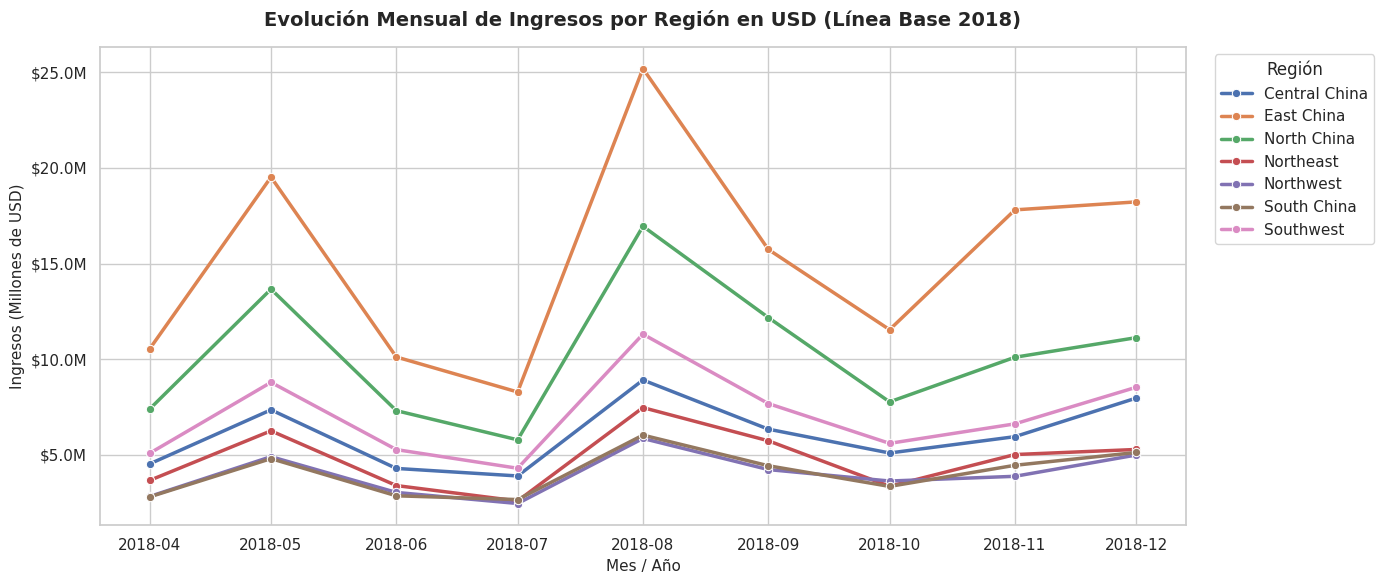

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 2. Convertir ingresos a millones para mejor escala visual
baseline_2018['ingresos_millones'] = baseline_2018['ingresos_usd'] / 1e6

# 3. Gráfico de líneas por región
sns.lineplot(
    data=baseline_2018,
    x='date',
    y='ingresos_millones',
    hue='region_name',
    marker='o',
    linewidth=2.5
)

# 4. Títulos y etiquetas
plt.title('Evolución Mensual de Ingresos por Región en USD (Línea Base 2018)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes / Año', fontsize=11)
plt.ylabel('Ingresos (Millones de USD)', fontsize=11)
plt.xticks(rotation=0)

# 5. Formatear eje Y con signo de dólar y sufijo 'M'
ax = plt.gca()
ax.yaxis.set_major_formatter('${x:,.1f}M')

plt.legend(title='Región', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

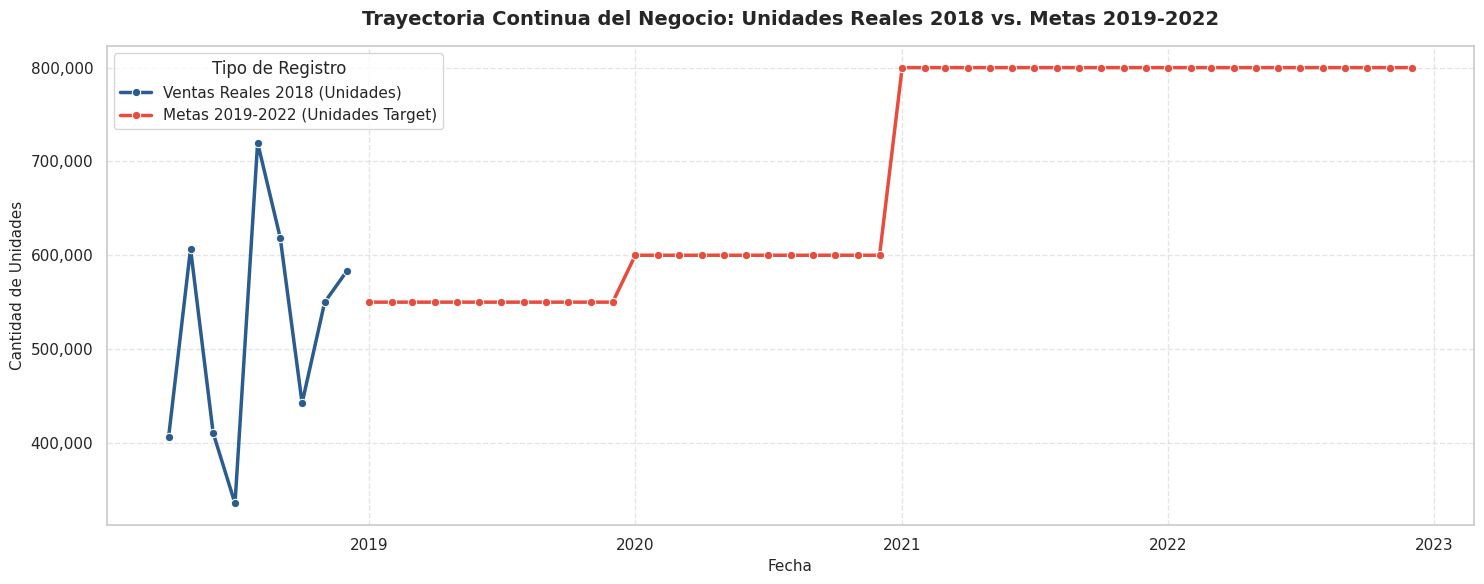

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Gráfico de líneas
sns.lineplot(
    data=global_unidades,
    x='date',
    y='cantidad',
    hue='tipo',
    palette={'Ventas Reales 2018 (Unidades)': '#2b5c8f', 'Metas 2019-2022 (Unidades Target)': '#e74c3c'},
    marker='o',
    linewidth=2.5
)

# Títulos y etiquetas
plt.title('Trayectoria Continua del Negocio: Unidades Reales 2018 vs. Metas 2019-2022', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Cantidad de Unidades', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Formatear eje Y con separadores de miles
ax = plt.gca()
ax.yaxis.set_major_formatter('{x:,.0f}')

plt.legend(title='Tipo de Registro', loc='upper left')
plt.tight_layout()
plt.show()

### Feature Engineering

In [14]:
# 1. Unificar las series históricas (Ventas 2018 + Metas 2019-2022) en una estructura homogénea
v_base = baseline_2018[['date', 'region_name', 'unidades_vendidas']].copy()
v_base.rename(columns={'unidades_vendidas': 'demand_qty'}, inplace=True)

m_base = targets_clean[['date', 'region_name', 'target_val_num']].copy()
m_base.rename(columns={'target_val_num': 'demand_qty'}, inplace=True)

# Dataset unificado
df_ts = pd.concat([v_base, m_base], ignore_index=True)
df_ts = df_ts.sort_values(by=['region_name', 'date']).reset_index(drop=True)


print(" DATASET TEMPORAL UNIFICADO (2018 - 2022)")
print("-" * 60)
print(f"• Total de observaciones: {len(df_ts)}")
print(f"• Rango de fechas: {df_ts['date'].min().strftime('%Y-%m')} a {df_ts['date'].max().strftime('%Y-%m')}")

 DATASET TEMPORAL UNIFICADO (2018 - 2022)
------------------------------------------------------------
• Total de observaciones: 399
• Rango de fechas: 2018-04 a 2022-12


In [15]:
# 399 observaciones (63 + 336)

In [16]:
import numpy as np

# 1. Variables de Calendario
df_ts['year'] = df_ts['date'].dt.year
df_ts['month'] = df_ts['date'].dt.month
df_ts['quarter'] = df_ts['date'].dt.quarter

# 2. Codificación Cíclica de la Estacionalidad (Seno / Coseno)
df_ts['sin_month'] = np.sin(2 * np.pi * df_ts['month'] / 12)
df_ts['cos_month'] = np.cos(2 * np.pi * df_ts['month'] / 12)

# 3. Lags por región
for lag in [1, 2, 3, 12]:
    df_ts[f'lag_{lag}'] = df_ts.groupby('region_name')['demand_qty'].shift(lag)

# 4. Promedios Móviles (Rolling Windows de 3 y 6 meses por región)
df_ts['rolling_mean_3m'] = df_ts.groupby('region_name')['demand_qty'].shift(1).rolling(window=3).mean()
df_ts['rolling_mean_6m'] = df_ts.groupby('region_name')['demand_qty'].shift(1).rolling(window=6).mean()

# Confirmación

print("MATRIZ DE CARACTERÍSTICAS TEMPORALES COMPLETADA")
print("-" * 65)
print(f"• Columnas totales generadas: {df_ts.shape[1]}")
print("• Predictoores creados:", list(df_ts.columns[3:]))

display(df_ts.head())

MATRIZ DE CARACTERÍSTICAS TEMPORALES COMPLETADA
-----------------------------------------------------------------
• Columnas totales generadas: 14
• Predictoores creados: ['year', 'month', 'quarter', 'sin_month', 'cos_month', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_mean_3m', 'rolling_mean_6m']


,date,region_name,demand_qty,year,month,quarter,sin_month,cos_month,lag_1,lag_2,lag_3,lag_12,rolling_mean_3m,rolling_mean_6m
0,2018-04-01,Central China,49398,2018,4,2,8.660254e-01,-0.500000,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-05-01,Central China,69368,2018,5,2,5.000000e-01,-0.866025,49398.0,NaN,NaN,NaN,NaN,NaN
2,2018-06-01,Central China,48918,2018,6,2,1.224647e-16,-1.000000,69368.0,49398.0,NaN,NaN,NaN,NaN
3,2018-07-01,Central China,43886,2018,7,3,-5.000000e-01,-0.866025,48918.0,69368.0,49398.0,NaN,55894.666667,NaN
4,2018-08-01,Central China,79960,2018,8,3,-8.660254e-01,-0.500000,43886.0,48918.0,69368.0,NaN,54057.333333,NaN


In [17]:

print("DEMOSTRACIÓN DE DINÁMICA DE LAGS EN REGION EAST CHINA (2018-2019)")
print("-" * 65)

# Filtrar una región específica en la transición de ventas reales a metas
muestra_dinamica = df_ts[df_ts['region_name'] == 'East China'].head(12)[
    ['date', 'region_name', 'demand_qty', 'lag_1', 'lag_2', 'rolling_mean_3m']
]

display(muestra_dinamica)

DEMOSTRACIÓN DE DINÁMICA DE LAGS EN REGION EAST CHINA (2018-2019)
-----------------------------------------------------------------


,date,region_name,demand_qty,lag_1,lag_2,rolling_mean_3m
57,2018-04-01,East China,116801,NaN,NaN,NaN
58,2018-05-01,East China,181785,116801.0,NaN,NaN
59,2018-06-01,East China,115062,181785.0,116801.0,NaN
60,2018-07-01,East China,92598,115062.0,181785.0,137882.666667
61,2018-08-01,East China,218953,92598.0,115062.0,129815.000000
62,2018-09-01,East China,176300,218953.0,92598.0,142204.333333
63,2018-10-01,East China,126120,176300.0,218953.0,162617.000000
64,2018-11-01,East China,185608,126120.0,176300.0,173791.000000
65,2018-12-01,East China,171790,185608.0,126120.0,162676.000000
66,2019-01-01,East China,150000,171790.0,185608.0,161172.666667


In [31]:
# Eliminar únicamente los registros iniciales afectados por el cálculo de lags&rolling
cols_lags = [c for c in df_ts.columns if 'lag' in c or 'rolling' in c]
df_model = df_ts.dropna(subset=cols_lags).copy().reset_index(drop=True)


print(" MATRIZ DE ENTRENAMIENTO (SIN VALORES NULOS)")
print("-" * 60)
print(f"• Registros totales listos para modelar: {len(df_model)}")
print(f"• Rango de fechas final: {df_model['date'].min().strftime('%Y-%m')} a {df_model['date'].max().strftime('%Y-%m')}")

 MATRIZ DE ENTRENAMIENTO (SIN VALORES NULOS)
------------------------------------------------------------
• Registros totales listos para modelar: 315
• Rango de fechas final: 2019-04 a 2022-12


In [19]:
# Período filtrado desde abril 2019 a dic 2022 es igual a 45 meses
# 315 observaciones = 45 * 7 Regiones

### One-Hot Encoding & Features

In [20]:
# 1. Variables Dummies(drop_first=True evita multicolinealidad)
df_encoded = pd.get_dummies(df_model, columns=['region_name'], drop_first=True, dtype=int)

# 2. Identificar las columnas regionales generadas
region_cols = [col for col in df_encoded.columns if col.startswith('region_name_')]

# 3. Definir la lista completa de predictores (Features)
features_complete = [
    'year', 'month', 'quarter', 'sin_month', 'cos_month',
    'lag_1', 'lag_2', 'lag_3', 'lag_12',
    'rolling_mean_3m', 'rolling_mean_6m'
] + region_cols

target = 'demand_qty'

# 4. Split respetando la secuencia del tiempo (Train: 2019-2021 | Test: 2022)
train_encoded = df_encoded[df_encoded['year'] < 2022]
test_encoded = df_encoded[df_encoded['year'] == 2022]

X_train, y_train = train_encoded[features_complete], train_encoded[target]
X_test, y_test = test_encoded[features_complete], test_encoded[target]


print(" MATRIZ CON ONE-HOT ENCODING Y TRAIN/TEST SPLIT COMPLETADOS")
print("-" * 65)
print(f"• Predictores totales en X: {len(features_complete)}")
print(f"• Columnas regionales agregadas: {region_cols}")
print(f"• Muestras de Entrenamiento (Train 2019-2021): {X_train.shape[0]}")
print(f"• Muestras de Evaluación (Test 2022): {X_test.shape[0]}")

 MATRIZ CON ONE-HOT ENCODING Y TRAIN/TEST SPLIT COMPLETADOS
-----------------------------------------------------------------
• Predictores totales en X: 17
• Columnas regionales agregadas: ['region_name_East China', 'region_name_North China', 'region_name_Northeast', 'region_name_Northwest', 'region_name_South China', 'region_name_Southwest']
• Muestras de Entrenamiento (Train 2019-2021): 231
• Muestras de Evaluación (Test 2022): 84


In [21]:
# Train(2019-2021): 33 meses * 7 regiones = 231 observaciones
# Test (2022): 12 meses * 7 regiones = 84 observaciones

## Entrenamiento y Predicción (Random ForestRegressor)

In [34]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Entrenar el modelo directamente con las unidades reales (sin log1p)
rf_base_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base_model.fit(X_train, y_train)

# 2. Predecir en escala real
y_pred_base = rf_base_model.predict(X_test)

# 3. Métricas en unidades reales
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("MODELO RANDOM FOREST BASE (SIN LOG1P) ENTRENADO")
print("-" * 50)
print(f"• MAE:  {mae_base:,.2f} unidades")
print(f"• RMSE: {rmse_base:,.2f} unidades")
print(f"• R²:   {r2_base:.4f}")

MODELO RANDOM FOREST BASE (SIN LOG1P) ENTRENADO
--------------------------------------------------
• MAE:  1,351.19 unidades
• RMSE: 4,040.35 unidades
• R²:   0.9956


In [22]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Transformar variable objetivo a escala logarítmica
y_train_log = np.log1p(y_train)

# 2. Entrenar el modelo
rf_log_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_log_model.fit(X_train, y_train_log)

# 3. Predecir y revertir transformación
y_pred_log = rf_log_model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # Definimos 'y_pred' estandarizado para las celdas siguientes

# 4. Métricas en unidades reales
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print(" MODELO RANDOM FOREST (LOG1P) ENTRENADO")
print("-" * 50)
print(f"• MAE:  {mae:,.2f} unidades")
print(f"• RMSE: {rmse:,.2f} unidades")
print(f"• R²:   {r2:.4f}")

 MODELO RANDOM FOREST (LOG1P) ENTRENADO
--------------------------------------------------
• MAE:  623.15 unidades
• RMSE: 3,708.44 unidades
• R²:   0.9963


In [35]:
# DataFrame comparativo
df_comparativa = pd.DataFrame({
    'Enfoque': ['Random Forest Estándar', 'Random Forest + Log1p'],
    'MAE (Unidades)': [f"{mae_base:,.2f}", f"{mae:,.2f}"],
    'RMSE (Unidades)': [f"{rmse_base:,.2f}", f"{rmse:,.2f}"],
    'R² Score': [f"{r2_base:.4f}", f"{r2:.4f}"]
})

display(df_comparativa)

,Enfoque,MAE (Unidades),RMSE (Unidades),R² Score
0,Random Forest Estándar,"1,351.19","4,040.35",0.9956
1,Random Forest + Log1p,623.15,"3,708.44",0.9963


## Construcción del DataFrame de Resultados 2022

In [30]:
# Consolidar DataFrame de resultados de prueba (Año 2022)
df_results = df_model.loc[test_encoded.index, ['date', 'region_name', 'demand_qty']].copy()
df_results['pred_qty'] = y_pred
df_results['date'] = pd.to_datetime(df_results['date'])

df_results.head()

,date,region_name,demand_qty,pred_qty
33,2022-01-01,Central China,75000,75000.0
34,2022-02-01,Central China,75000,75000.0
35,2022-03-01,Central China,75000,75000.0
36,2022-04-01,Central China,75000,75000.0
37,2022-05-01,Central China,75000,75000.0


## Visualización de Demanda Real vs. Predicha por Región

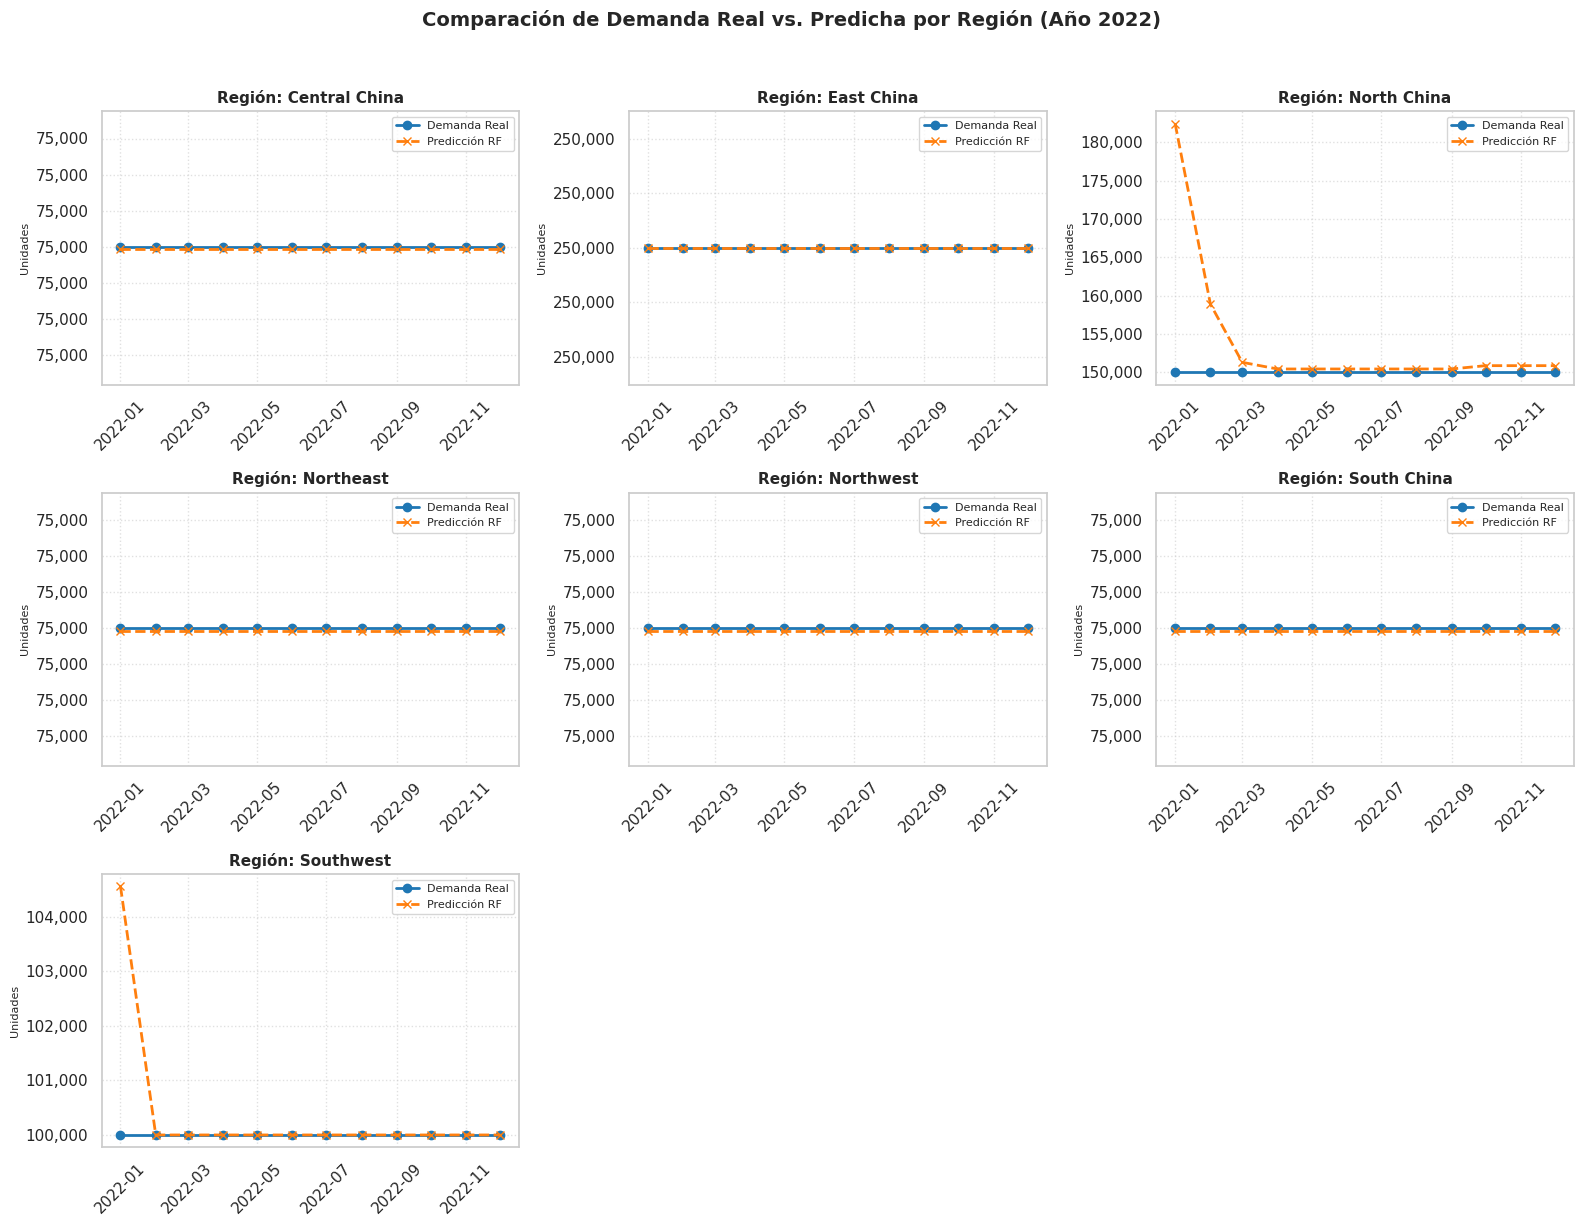

In [32]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

plt.figure(figsize=(16, 12))
regiones = sorted(df_results['region_name'].unique())

for i, region in enumerate(regiones, 1):
    ax = plt.subplot(3, 3, i)
    data_region = df_results[df_results['region_name'] == region].sort_values('date')

    # Curvas de Demanda
    ax.plot(data_region['date'], data_region['demand_qty'],
            marker='o', label='Demanda Real', color='#1f77b4', linewidth=2)
    ax.plot(data_region['date'], data_region['pred_qty'],
            marker='x', linestyle='--', label='Predicción RF', color='#ff7f0e', linewidth=2)

    # Formato gráfico
    ax.set_title(f'Región: {region}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Unidades', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

    # Formato de ejes numéricos sin notación científica
    ax.ticklabel_format(style='plain', useOffset=False, axis='y')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=8)

plt.suptitle('Comparación de Demanda Real vs. Predicha por Región (Año 2022)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1811/2194375687.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


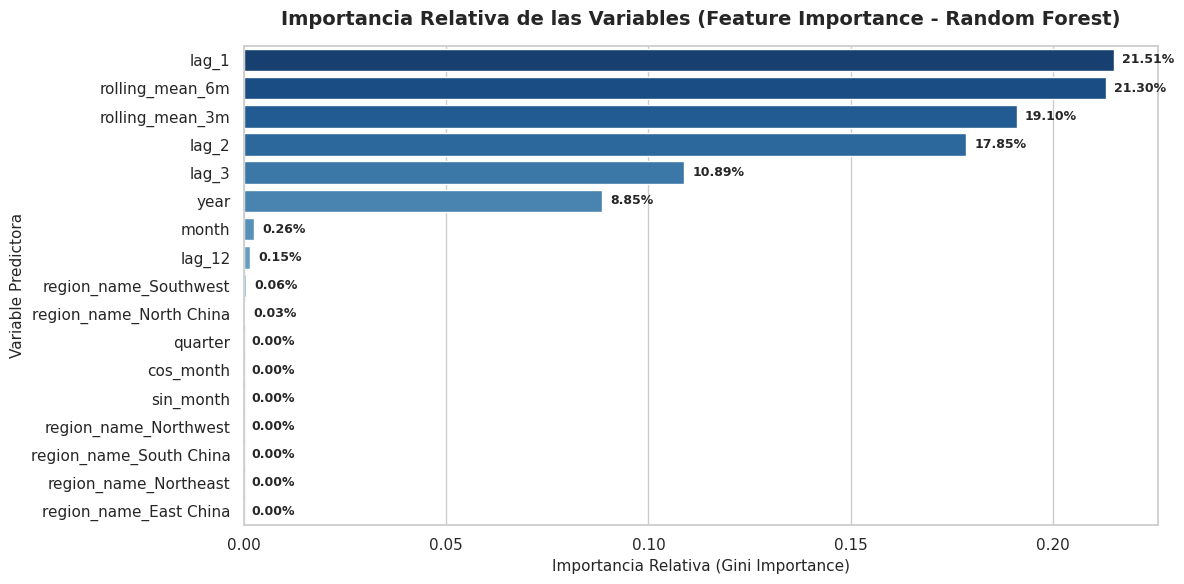

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer la importancia de las variables del modelo entrenado
importance_df = pd.DataFrame({
    'Feature': features_complete,
    'Importance': rf_log_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 2. Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Graficar la importancia usando barras horizontales
palette = sns.color_palette("Blues_r", n_colors=len(importance_df))
ax = sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette=palette
)

# 4. Títulos y etiquetas de los ejes
plt.title('Importancia Relativa de las Variables (Feature Importance - Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importancia Relativa (Gini Importance)', fontsize=11)
plt.ylabel('Variable Predictora', fontsize=11)

# 5. Agregar valores porcentuales en cada barra
for index, value in enumerate(importance_df['Importance']):
    ax.text(value + 0.002, index, f'{value*100:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



In [26]:
import pandas as pd
import numpy as np

# 1. Consolidar el DataFrame de predicciones finales 2022 con el modelo Random Forest + Log1p
df_final_2022 = df_model.loc[test_encoded.index, ['date', 'year', 'month', 'region_name', 'demand_qty']].copy()

# Asignar predicciones suavizadas
df_final_2022['pred_demand_rf_log'] = y_pred_log.round(2)
df_final_2022['error_absoluto'] = (df_final_2022['demand_qty'] - df_final_2022['pred_demand_rf_log']).abs().round(2)
df_final_2022['error_porcentual_%'] = ((df_final_2022['error_absoluto'] / df_final_2022['demand_qty']) * 100).round(2)

# Ordenar cronológicamente por región
df_final_2022 = df_final_2022.sort_values(by=['region_name', 'date']).reset_index(drop=True)

# Exportar dataset de predicciones detalladas 2022 a CSV
df_final_2022.to_csv('predicciones_demanda_2022_final.csv', index=False)

# 2. Generar y exportar la tabla consolidada de métricas regionales
resumen_metricas_region = df_final_2022.groupby('region_name').agg(
    Demanda_Promedio_Mensual=('demand_qty', 'mean'),
    Demanda_Total_2022=('demand_qty', 'sum'),
    MAE_Unidades=('error_absoluto', 'mean'),
    MAPE_Porcentual=('error_porcentual_%', 'mean')
).reset_index()

resumen_metricas_region['Demanda_Promedio_Mensual'] = resumen_metricas_region['Demanda_Promedio_Mensual'].round(2)
resumen_metricas_region['Demanda_Total_2022'] = resumen_metricas_region['Demanda_Total_2022'].round(2)
resumen_metricas_region['MAE_Unidades'] = resumen_metricas_region['MAE_Unidades'].round(2)
resumen_metricas_region['MAPE_Porcentual'] = resumen_metricas_region['MAPE_Porcentual'].round(2)

# Ordenar por demanda total descendente
resumen_metricas_region = resumen_metricas_region.sort_values(by='Demanda_Total_2022', ascending=False).reset_index(drop=True)

# Exportar resumen de métricas regionales a CSV
resumen_metricas_region.to_csv('metricas_desempeno_por_region_2022.csv', index=False)

print("=" * 70)
print(" ARCHIVOS CSV GENERADOS Y EXPORTADOS CON ÉXITO")
print("=" * 70)
print("1. 'predicciones_demanda_2022_final.csv' (Predicciones mensuales por región)")
print("2. 'metricas_desempeno_por_region_2022.csv' (Métricas de precisión agrupadas)")
print("-" * 70)
print("\n--- RESUMEN DE MÉTRICAS REGIONALES ---")
display(resumen_metricas_region)

 ARCHIVOS CSV GENERADOS Y EXPORTADOS CON ÉXITO
1. 'predicciones_demanda_2022_final.csv' (Predicciones mensuales por región)
2. 'metricas_desempeno_por_region_2022.csv' (Métricas de precisión agrupadas)
----------------------------------------------------------------------

--- RESUMEN DE MÉTRICAS REGIONALES ---


,region_name,Demanda_Promedio_Mensual,Demanda_Total_2022,MAE_Unidades,MAPE_Porcentual
0,East China,250000.0,3000000,249987.57,100.00
1,North China,150000.0,1800000,149988.06,99.99
2,Southwest,100000.0,1200000,99988.49,99.99
3,Central China,75000.0,900000,74988.77,99.99
4,Northeast,75000.0,900000,74988.77,99.99
5,Northwest,75000.0,900000,74988.77,99.99
6,South China,75000.0,900000,74988.77,99.99


In [27]:
# import time
# from google.colab import files

# # Descarga del primer archivo
# files.download('predicciones_demanda_2022_final.csv')

# # Pausa de 2 segundos para no saturar el navegador
# time.sleep(2)

# # Descarga del segundo archivo
# files.download('metricas_desempeno_por_region_2022.csv')